# World Wrestling Entertainment (WWE) is an American professional wrestling promotion company

In [3]:
import matplotlib.pyplot as plt
from matplotlib.image import imread
from matplotlib.patches import Patch
import duckdb
import pandas as pd

In [4]:
conn = duckdb.connect("/Users/marietolteca/Documents/MEDS/WWE-database/wwe_database.db")
cur = conn.cursor()

In [5]:
cur.execute("""
SELECT s.superstar_name,
       ROUND(AVG(m.CageMatchRating), 2) AS AvgRating,
       COUNT(*) AS MatchCount
FROM superstars s
JOIN match_rating m ON s.MatchIndex = m.Index
JOIN events e ON e.Date = m.Date AND e.Promotion = m.Promotion
WHERE e.Event = 'WWE WrestleMania'
  AND m.CageMatchRating IS NOT NULL
GROUP BY s.superstar_name
ORDER BY AvgRating DESC
LIMIT 20;
""")

In [ ]:
#cur.df()         # pandas DataFrame ← best for analysis

In [6]:
# Save query from all superstars in Wrestlemania with most viewed total votes
superstar_wm = cur.df()

# Print the first five rows
superstar_wm

,superstar_name,AvgRating,MatchCount
0,Trick Williams,9.04,1
1,Je'Von Evans,9.04,1
2,Oba Femi,9.04,1
3,CM Punk,8.80,1
4,Dragon Lee,8.65,1
5,Ilja Dragunov,8.65,1
6,JD McDonagh,8.65,1
7,Axiom,8.57,2
8,Tank Ledger,8.50,1
9,Nathan Frazer,8.50,1


In [7]:
print(superstar_wm.head(10))

   superstar_name  AvgRating  MatchCount
0  Trick Williams       9.04           1
1    Je'Von Evans       9.04           1
2        Oba Femi       9.04           1
3         CM Punk       8.80           1
4      Dragon Lee       8.65           1
5   Ilja Dragunov       8.65           1
6     JD McDonagh       8.65           1
7           Axiom       8.57           2
8     Tank Ledger       8.50           1
9   Nathan Frazer       8.50           1


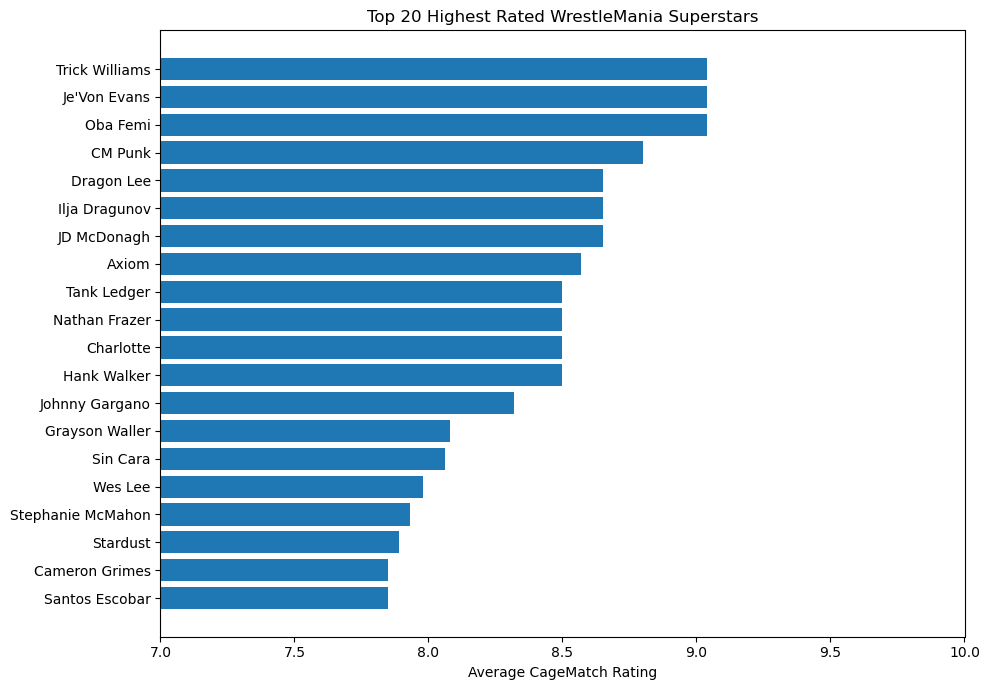

In [8]:
df_sorted = superstar_wm.sort_values("AvgRating", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(df_sorted["superstar_name"], df_sorted["AvgRating"])

ax.set_xlabel("Average CageMatch Rating")
ax.set_title("Top 20 Highest Rated WrestleMania Superstars")
ax.set_xlim(7, 10)  # zoom in since all values are between 8-9
plt.tight_layout()
plt.show()

# Final Viz - Top 20 Highest Rating WrestleMania Superstars (2015-2020)

/var/folders/7j/l4df3nhs4jg2_5kxg79fnwww0000gn/T/ipykernel_3277/2745960880.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


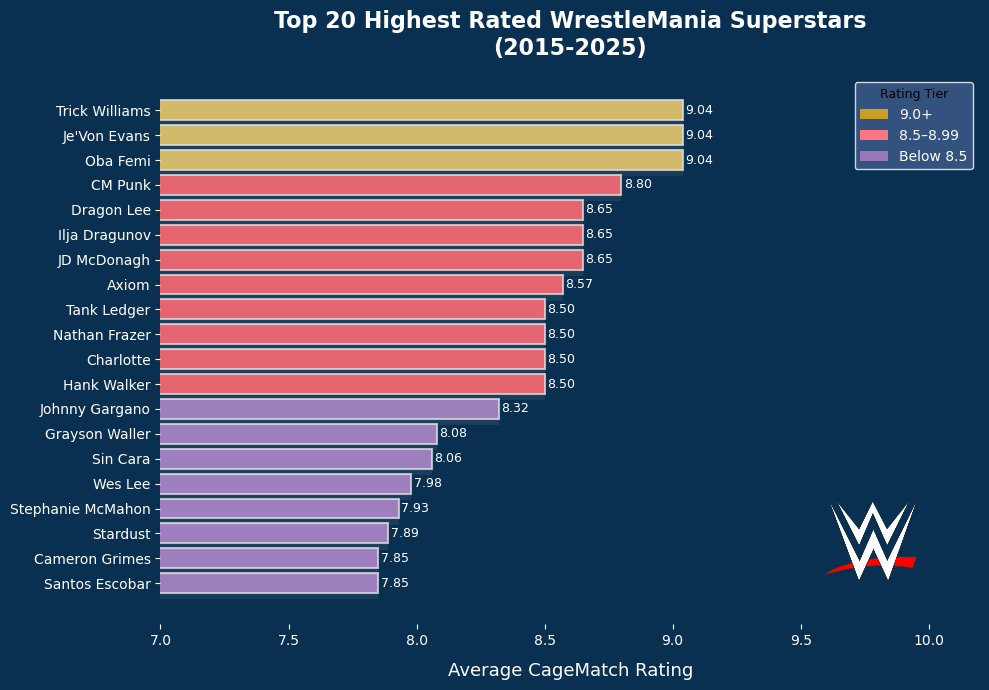

In [11]:
colors = df_sorted["AvgRating"].apply(
    lambda x: "#D1B560" if x >= 9.0 else "#e45a66" if x >= 8.5 else "#9877B9"
)

bg_color = "#0A3051"

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(bg_color)        # figure background
ax.set_facecolor(bg_color)               # plot area background

bars = ax.barh(
    df_sorted["superstar_name"],
    df_sorted["AvgRating"],
    color=colors,
    edgecolor="#e1e2e2c1",
    linewidth=1.5
)

# Glow effect — draw a wider transparent bar behind each bar
for bar in bars:
    ax.barh(
        bar.get_y() + bar.get_height() / 3,
        bar.get_width(),
        height=bar.get_height() * 1.3,
        color="#f6f6f6",
        alpha=0.07,
        left=bar.get_x()
    )

# Value labels
for i, val in enumerate(df_sorted["AvgRating"]):
    ax.text(val + 0.01, i, f"{val:.2f}", va="center", fontsize=9, color="white")

ax.set_xlabel("Average CageMatch Rating", color="white", fontsize=13, labelpad=10)
ax.set_title("Top 20 Highest Rated WrestleMania Superstars\n(2015-2025)", color="white",fontsize=16, fontweight="bold", pad=15)

ax.set_xlim(7, 10.2)
ax.tick_params(colors="white")
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)

# Legend colors
legend_elements = [
    Patch(facecolor="#C8A028", label="9.0+"),
    Patch(facecolor="#ff7681", label="8.5–8.99"),
    Patch(facecolor="#9877B9", label="Below 8.5")
]

# Background color for legend
ax.legend(handles=legend_elements, title="Rating Tier",
          facecolor="#3f5b8a", labelcolor="white",
          title_fontsize=9, edgecolor="white")

# Add LOGO
logo = imread("WWE-logo.png")
logo_ax = fig.add_axes([0.80, 0.02, 0.15, 0.4])  # [left, bottom, width, height]
logo_ax.imshow(logo)
logo_ax.axis("off")

plt.tight_layout()
plt.show()

# Close Connection

In [12]:
conn.close()